# Day 27 - GAN - 生成对抗网络

> GAN: 生成器 (伪造) vs 判别器 (鉴定), 互相进化
>
> 核心: 零和博弈 — 生成器想让判别器犯错, 判别器想不被骗

---

## GAN 的核心思想

```
判别器 D (Discriminator):                   生成器 G (Generator):
  输入: 真实图像 / 伪造图像                     输入: 随机噪声 z
  输出: 真(1) 或 假(0)                         输出: 伪造图像
  目标: 准确区分真假                           目标: 让 D 以为是真

训练过程:
  固定 G, 训练 D:   D 学如何区分真假
  固定 D, 训练 G:   G 学如何骗过 D
  → 交替训练, 直到 G 生成的内容 D 无法分辨
```

### 类比: 假钞犯 vs 警察

```
假钞犯 (G) 不断制造更逼真的假钞
警察   (D) 不断学习识别最新的假钞
双方博弈 → 假钞越来越真, 警察越来越敏锐
```

In [2]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

print('=' * 40)
print('Day 27 - GAN')
print('=' * 40)

Day 27 - GAN


## 1. 生成器 + 判别器

> 用最简单的全连接网络, 生成 2D 点
>
> 真实分布: 圆形 (高斯分布)

In [4]:
# ============================================
# 定义生成器和判别器
# ============================================

class Generator(nn.Module):
    """生成器: 噪声 z → 伪造数据 (2D 点)"""
    def __init__(self, z_dim=2, hidden=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 2),
        )
    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    """判别器: 2D 点 → 真(1) / 假(0)"""
    def __init__(self, hidden=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden), nn.LeakyReLU(0.2),
            nn.Linear(hidden, hidden), nn.LeakyReLU(0.2),
            nn.Linear(hidden, 1), nn.Sigmoid(),
        )
    def forward(self, x):
        return self.net(x)

G = Generator()
D = Discriminator()
print(f'生成器: {sum(p.numel() for p in G.parameters()):,} 参数')
print(f'判别器: {sum(p.numel() for p in D.parameters()):,} 参数')

生成器: 354 参数
判别器: 337 参数


## 2. 训练 GAN

> 真实数据: 以原点为中心的高斯分布 (圆形)
>
> 生成器: 从随机噪声学出圆形分布

In [5]:
# ============================================
# 训练 GAN
# ============================================

opt_G = optim.Adam(G.parameters(), lr=0.01)
opt_D = optim.Adam(D.parameters(), lr=0.01)
criterion = nn.BCELoss()  # 二分类交叉熵

g_losses, d_losses = [], []

for epoch in range(3000):
    # ---- 真实数据: 从高斯分布采样 ----
    real_data = torch.randn(64, 2)  # (64, 2)
    real_labels = torch.ones(64, 1)  # 真实 = 1

    # ---- 伪造数据 ----
    z = torch.randn(64, 2)  # 随机噪声
    fake_data = G(z)
    fake_labels = torch.zeros(64, 1)  # 伪造 = 0

    # ========== 训练判别器 D ==========
    opt_D.zero_grad()
    d_real = D(real_data)
    d_fake = D(fake_data.detach())
    loss_D = criterion(d_real, real_labels) + criterion(d_fake, fake_labels)
    loss_D.backward()
    opt_D.step()

    # ========== 训练生成器 G ==========
    opt_G.zero_grad()
    z = torch.randn(64, 2)  # 新噪声
    fake_data = G(z)
    d_fake = D(fake_data)
    # G 希望 D 输出 1 (误认为真)
    loss_G = criterion(d_fake, real_labels)
    loss_G.backward()
    opt_G.step()

    g_losses.append(loss_G.item())
    d_losses.append(loss_D.item())

    if (epoch + 1) % 500 == 0:
        print(f'Epoch {epoch+1:>4d}/3000 | D Loss = {loss_D.item():.4f} | G Loss = {loss_G.item():.4f}')

Epoch  500/3000 | D Loss = 62.9480 | G Loss = 0.0210
Epoch 1000/3000 | D Loss = 0.3541 | G Loss = 1.8632
Epoch 1500/3000 | D Loss = 0.0599 | G Loss = 3.8286
Epoch 2000/3000 | D Loss = 0.3324 | G Loss = 3.4609
Epoch 2500/3000 | D Loss = 0.0955 | G Loss = 4.0617
Epoch 3000/3000 | D Loss = 0.0203 | G Loss = 4.3459


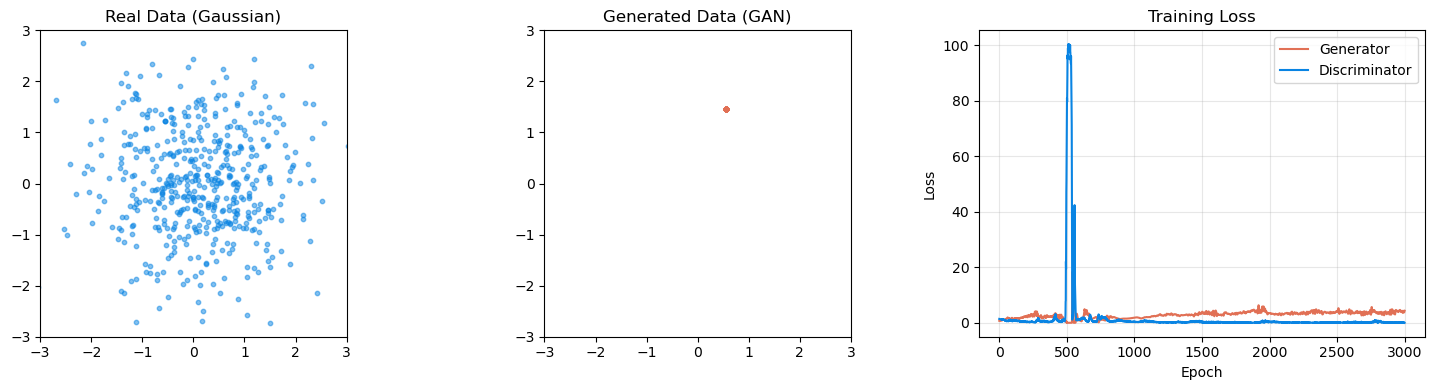

✅ GAN 学会了从噪声生成与真实分布相似的 2D 点


In [6]:
# ============================================
# 结果可视化
# ============================================

with torch.no_grad():
    z = torch.randn(500, 2)
    generated = G(z).numpy()
    real = torch.randn(500, 2).numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 真实分布
ax = axes[0]
ax.scatter(real[:, 0], real[:, 1], alpha=0.5, s=10, color='#0984e3')
ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
ax.set_title('Real Data (Gaussian)', fontsize=12)
ax.set_aspect('equal')

# 生成分布
ax = axes[1]
ax.scatter(generated[:, 0], generated[:, 1], alpha=0.5, s=10, color='#e17055')
ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
ax.set_title('Generated Data (GAN)', fontsize=12)
ax.set_aspect('equal')

# 训练损失
ax = axes[2]
ax.plot(g_losses, label='Generator', lw=1.5, color='#e17055')
ax.plot(d_losses, label='Discriminator', lw=1.5, color='#0984e3')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Training Loss')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('day27_gan_result.png', dpi=120)
plt.show()

print('✅ GAN 学会了从噪声生成与真实分布相似的 2D 点')

## 3. GAN 的变体

> 原始 GAN 训练不稳定, 有很多改进版本

### 常见问题

```
1. 模式崩溃 (Mode Collapse)
   生成器只学会生成一种样本, 缺乏多样性
   例: 应该生成 0-9, 但只会生成 1

2. 不收敛
   G 和 D 互相博弈, 损失来回震荡

3. 判别器太强
   D 太容易识破 G, G 学不到东西
```

### 主要变体

| 模型 | 改进 | 效果 |
|:----|:-----|:-----|
| **DCGAN** | 用卷积代替全连接 | 图像生成更稳定 |
| **WGAN** | Wasserstein 距离代替 BCE | 解决模式崩溃 |
| **WGAN-GP** | 梯度惩罚 | 训练更稳定 |
| **LSGAN** | 最小二乘损失 | 高质量图像 |
| **CycleGAN** | 循环一致性损失 | 图像风格迁移 |
| **StyleGAN** | 风格控制 | 人脸生成 SOTA |
| **pix2pix** | 条件 GAN | 图像翻译 |

---

# Day 27 完成!

## 总结

| 概念 | 一句话 |
|------|--------|
| **GAN** | 生成器(伪造) vs 判别器(鉴定), 零和博弈 |
| **G** | 从噪声生成数据, 目标是骗过 D |
| **D** | 判断真假, 目标是识破 G |
| **交替训练** | 固定一方, 训练另一方, 反复迭代 |
| **模式崩溃** | G 只生成同一种样本, 缺乏多样性 |

## 今天实现了什么

```
从零训练 GAN, 让生成器学会拟合 2D 高斯分布
生成器: 噪声 z → 伪造点
判别器: 点 → 真(1)/假(0)
训练后: 生成点的分布跟真实分布高度相似
```

## 明天: Stable Diffusion

```
GAN → 生成对抗, 交替训练
扩散模型 → 逐步去噪, 从噪声还原图像
Stable Diffusion 就是"扩散模型 + 文本条件"
```

## 作业 (2 题)

### 1. 调学习率
**位置:** cell-5, `lr=0.01`

改成 `lr=0.001` 和 `lr=0.1`, 观察训练稳定性:
- 学习率太大 → 震荡不收敛
- 学习率太小 → 生成器学不动

<details>
<summary>📖 答案</summary>
lr=0.001: 收敛慢, 需要更多 epoch
lr=0.1:   Loss 反复震荡, 很难稳定
GAN 对超参数很敏感, 0.01 是 2D 点的合适值
实际图像 GAN 常用 lr=0.0002 (Adam)
</details>

### 2. 改激活函数
**位置:** cell-3, `nn.ReLU()` 和 `nn.LeakyReLU(0.2)`

把 D 的 LeakyReLU 改成 ReLU, 训练还会稳定吗? 为什么?

<details>
<summary>📖 答案</summary>
LeakyReLU(0.2) → 负数也有小梯度, D 不容易"死"
ReLU → 负数梯度为 0, D 可能"死掉" (输出恒为 0)
GAN 里判别器通常用 LeakyReLU, 生成器用 ReLU
</details>